In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import norm, ttest_ind
import os, sys
sys.path.append(os.path.abspath("../src"))
from io_utils import load_data
from health_study import HealthStudyAnalizer

df = load_data()
df_clean = HealthStudyAnalizer(df).clean_df()

# Beskrivande analys – Grundläggande statistik

In [2]:
cols = ["age", "weight", "height", "systolic_bp", "cholesterol"]
stats = df_clean[cols].agg(["mean", "median", "min", "max"]).round(2)
stats

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


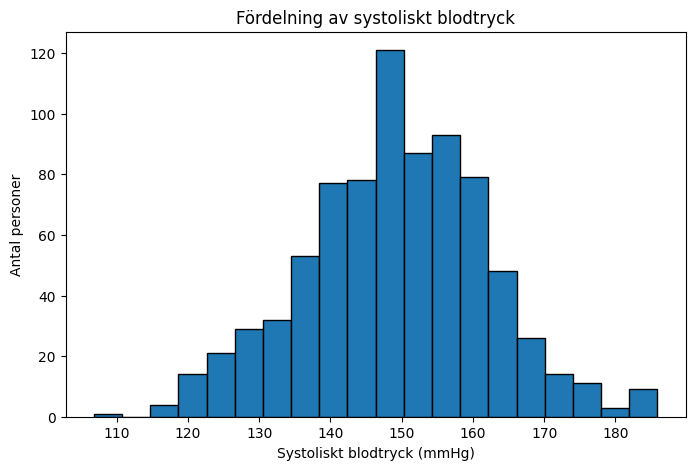

In [3]:
#Fördelning av systoliskt blodtryck graf
plt.figure(figsize=(8,5))
plt.hist(df_clean['systolic_bp'], bins=20, edgecolor='black')
plt.title("Fördelning av systoliskt blodtryck")
plt.xlabel("Systoliskt blodtryck (mmHg)")
plt.ylabel("Antal personer")
plt.show()

### Fördelningen av systoliskt blodtryck
- Diagrammet visar att de flesta personer har ett systoliskt blodtryck mellan 135 och 165 mmHg.
- Majoriteten ligger runt 145–150 mmHg, vilket visar den vanligaste nivån i gruppen.

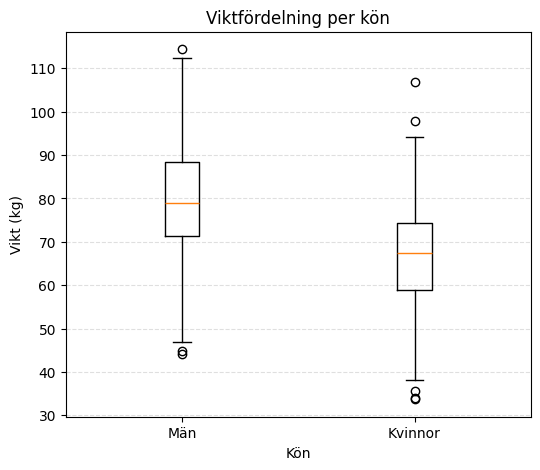

In [4]:
#Viktfördelning per kön graf
plt.figure(figsize=(6,5))
plt.boxplot([df_clean[df_clean['sex']=='M']['weight'],
             df_clean[df_clean['sex']=='F']['weight']],
            tick_labels=['Män', 'Kvinnor'])
plt.title("Viktfördelning per kön")
plt.xlabel("Kön")
plt.ylabel("Vikt (kg)")
plt.grid(axis='y', linestyle='--' , alpha=0.4)
plt.show()

### Viktfördelning per kön
- Diagrammet visar att män i genomsnitt väger mer än kvinnor.
- Medianvikten för män ligger runt 78–80 kg, medan kvinnors medianvikt ligger runt 65–68 kg.
- Spridningen är också något större bland män.
- Några outliers finns för båda könen, både lägre och högre vikter än genomsnittet.

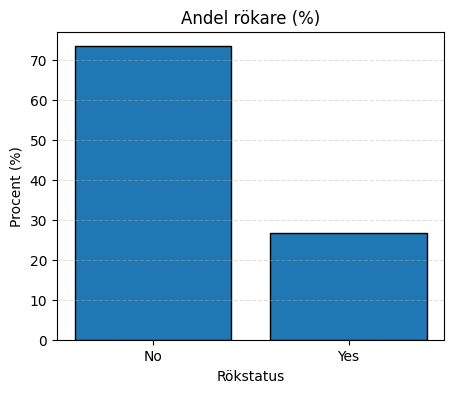

In [5]:
#Andel rökare graf
smoker_counts = df_clean['smoker'].value_counts(normalize=True) * 100
plt.figure(figsize=(5,4))
plt.bar(smoker_counts.index, smoker_counts.values, edgecolor='black')
plt.title("Andel rökare (%)")
plt.ylabel("Procent (%)")
plt.xlabel("Rökstatus")
plt.grid(axis='y', linestyle='--' , alpha=0.4)
plt.show()

### Andelen rökare
- Diagrammet visar att majoriteten av populationen inte röker, vilket kan ha en positiv inverkan på deras hälsa.

# Simulering och jämförelse av sjukdomsandel

In [6]:
#Andelen personer med sjukdom
disease_rate = df_clean["disease"].value_counts(normalize=True)[1]
disease_rate_percent = disease_rate * 100
print(f"Andelen personer med sjukdom: {disease_rate_percent:.2f}%")

#Andelen personer med sjukdom i simuleringen
np.random.seed(42)
simulated = np.random.binomial(1, disease_rate, size=1000)
simulated_rate = simulated.mean()
print(f"Andelen personer med sjukdom i simuleringen: {simulated_rate:.2%}")

Andelen personer med sjukdom: 5.88%
Andelen personer med sjukdom i simuleringen: 5.60%


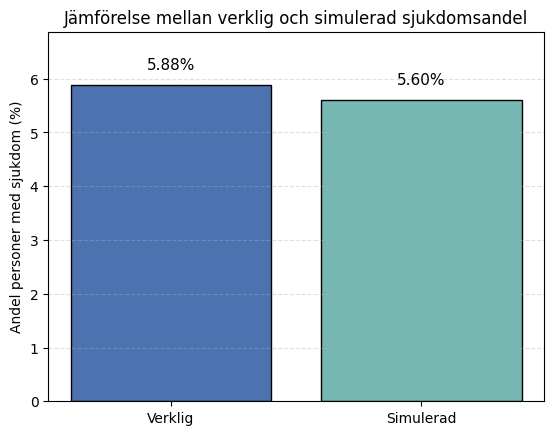

In [7]:
#Jämförelse mellan verklig och simulerad sjukdomsandel
labels = ['Verklig', 'Simulerad']
values = [disease_rate_percent, simulated_rate * 100] 
plt.bar(labels, values, color=['#4C72B0', '#76B7B2'], edgecolor='black', linewidth=1)
plt.ylabel('Andel personer med sjukdom (%)')
plt.title('Jämförelse mellan verklig och simulerad sjukdomsandel')
plt.ylim(0, max(values) + 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(values):
    plt.text(i, v+0.3, f"{v:.2f}%", ha='center', fontsize=11)
plt.show()

### Jämförelse mellan verklig och simulerad sjukdomsandel
- Den simulerade andelen (5,60%) ligger mycket nära den verkliga andelen (5,88%), vilket visar att simuleringen stämmer väl överens med verkligheten.

In [31]:
#Konfidensintervall med normalapproximation
x = df_clean["systolic_bp"]

mean = x.mean()
std = x.std(ddof=1)
n = len(x)
z = norm.ppf(0.975)

ci_norm_low = mean - z*(std/np.sqrt(n))
ci_norm_high = mean + z*(std/np.sqrt(n))

In [ ]:
#Konfidensintervall med Bootstrap
x = df_clean["systolic_bp"].values

B = 5000
boot_means = []
np.random.seed(42)

for _ in range(B):
    sample = np.random.choice(x, size=len(x), replace=True)
    boot_means.append(sample.mean())

ci_boot_low = np.percentile(boot_means, 2.5)
ci_boot_high = np.percentile(boot_means, 97.5)

In [39]:
# Jämförelse av konfidensintervall mellan normalapproximation och bootstrapmetoden
ci_table = pd.DataFrame({
    "Low": [ci_norm_low, ci_boot_low],
    "High": [ci_norm_high, ci_boot_high]
}, index=["Normal", "Bootstrap"])

print("95% konfidensintervall för systolic_bp\n")
print(ci_table.round(3))

95% konfidensintervall för systolic_bp

               Low     High
Normal     148.292  150.065
Bootstrap  148.314  150.087


## Jämförelse av konfidensintervall

- Normalapproximationen och bootstrapmetoden ger nästan identiska intervall, skillnaderna mellan de två metoderna är minimala, vilket tyder på att skattningen är stabil och inte känslig för valet av metod.

In [ ]:
#Hypotesprövning t-test (ensidig: rökare har högre blodtryck)
smokers = df_clean[df_clean["smoker"] == 'Yes']["systolic_bp"]
non_smokers = df_clean[df_clean["smoker"] == 'No']["systolic_bp"]

t_stat, p_value = ttest_ind(smokers, non_smokers, alternative='greater')

print("Medel blodtryck (rökare):", smokers.mean().round(3))
print("Medel blodtryck (icke-rökare):", non_smokers.mean().round(3))
print("t-statistik:", t_stat.round(3))
print("p-värde:", p_value.round(3))


Medel blodtryck (rökare): 149.525
Medel blodtryck (icke-rökare): 149.053
t-statistik: 0.461
p-värde: 0.322


In [ ]:
# Hypotesprövning bootstrap (ensidig: rökare har högre blodtryck)
np.random.seed(0)
n_boot=10_000
obs_diff= smokers.mean()-non_smokers.mean()
boot_diff= np.empty(n_boot)

for i in range(n_boot):
    smokers_boot=np.random.choice(smokers , size=len(smokers), replace=True)
    non_smokers_boot=np.random.choice(non_smokers , size=len(non_smokers), replace=True)
    boot_diff[i]=smokers_boot.mean()-non_smokers_boot.mean()

p_value_boot=np.mean(boot_diff>= obs_diff)

ci_low, ci_high = np.percentile(boot_diff, [2.5, 97.5])
(ci_low, ci_high)

print(obs_diff.round(3))
print(p_value_boot.round(3))
print((ci_low.round(3), ci_high.round(3)))

0.472
0.499
(np.float64(-1.56), np.float64(2.499))


## Kort förklaring (Bootstrap + t-test)

- Både t-testet och bootstrap-analysen visar att skillnaden i medel-blodtryck mellan rökare och icke-rökare är mycket liten och inte statistiskt signifikant. Det observerade medelvärdesskillnaden är nära noll, p-värdena är höga och konfidensintervallet innehåller noll.
Vi kan därför inte dra slutsatsen att rökare har högre blodtryck i detta dataset.